# Assignment 2

__Problem 1b__

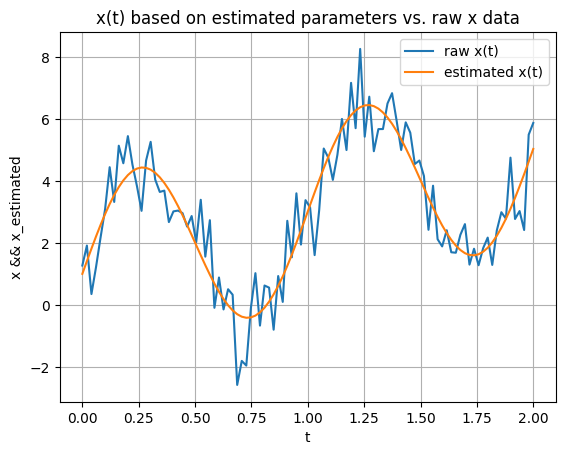

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.loadtxt("x.txt")
t = np.loadtxt("t.txt")
mu_w = 0
sigma_w_squared = 1
# print(x)

H_matrix = np.array([[1, time, np.sin(2*np.pi*time)] for time in t])
H_T = np.transpose(H_matrix)
H_T_H = np.matmul(H_T, H_matrix)
H_T_H_inverted = np.linalg.inv(H_T_H)
H_T_x = np.matmul(H_T, x)
# print(H_T_x)

theta_hat = np.matmul(H_T_H_inverted, H_T_x)
A_estimated, B_estimated, C_estimated = theta_hat
# print(theta_hat)

CRLB = sigma_w_squared * H_T_H_inverted
# print(CRLB)

x_estimated = A_estimated + B_estimated*t + C_estimated*np.sin(2*np.pi*t)

plt.plot(t, x, label="raw x(t)")
plt.plot(t, x_estimated, label="estimated x(t)")

plt.title("x(t) based on estimated parameters vs. raw x data")
plt.xlabel("t")
plt.ylabel("x && x_estimated")
plt.grid()
plt.legend()

plt.show()

__Problem 2b__

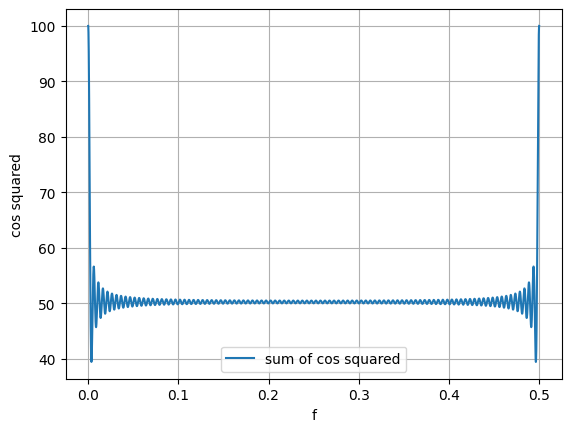

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sigma_squared_w = 1
mu_w = 0
f = np.linspace(0, 0.5, 10000)
N = 100
sum_cos_squared = 0

for n in range(N):
    sum_cos_squared += (np.cos(2*np.pi*f*n))**2

plt.plot(f, sum_cos_squared, label="sum of cos squared")
plt.xlabel("f")
plt.ylabel("cos squared")
plt.legend()
plt.grid()

plt.show()

As shown in plot, the sum of cos squared is almost constant when f is not too close to 0 and 0.5 and N sufficiently large. This term can be ignored (In MLE) as it will contribute equally for all f -> does not affect where optimum appears. 

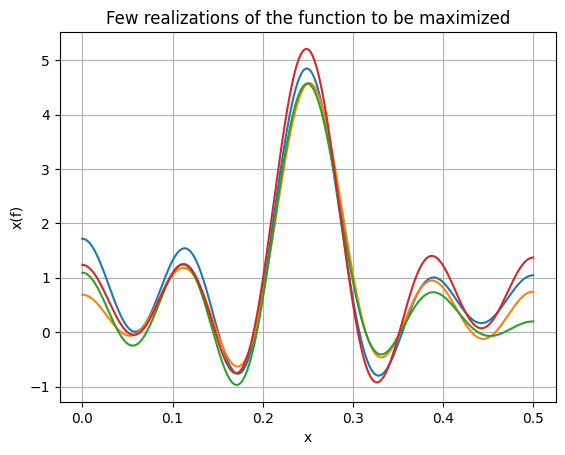

In [30]:
import random

N=10
f=0.25
f_axis = np.linspace(0, 0.5, 1000)
sigma_squared=0.01

sum0 = 0

for n in range(N):
    w = np.random.normal(0, np.sqrt(sigma_squared))
    x = (np.cos(2*np.pi*f*n) + w)
    sum0 += x * np.cos(2*np.pi*f_axis*n)

sum1 = 0

for n in range(N):
    w = np.random.normal(0, np.sqrt(sigma_squared))
    x = (np.cos(2*np.pi*f*n) + w)
    sum1 += x * np.cos(2*np.pi*f_axis*n)

sum2 = 0

for n in range(N):
    w = np.random.normal(0, np.sqrt(sigma_squared))
    x = (np.cos(2*np.pi*f*n) + w)
    sum2 += x * np.cos(2*np.pi*f_axis*n)

sum3 = 0

for n in range(N):
    w = np.random.normal(0, np.sqrt(sigma_squared))
    x = (np.cos(2*np.pi*f*n) + w)
    sum3 += x * np.cos(2*np.pi*f_axis*n)

plt.plot(f_axis, sum0)
plt.plot(f_axis, sum1)
plt.plot(f_axis, sum2)
plt.plot(f_axis, sum3)
plt.title("Few realizations of the function to be maximized")
plt.xlabel("x")
plt.ylabel("x(f)")
plt.grid()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


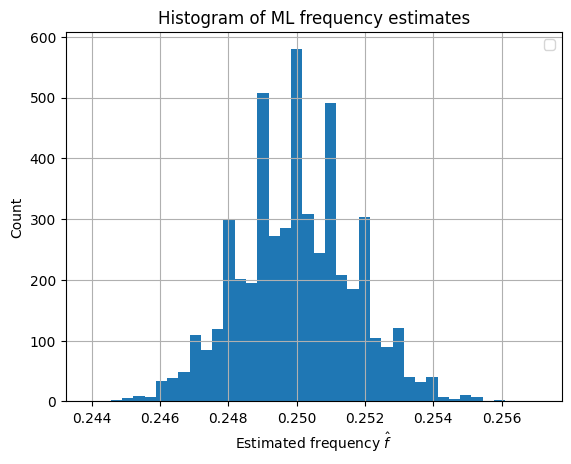

In [49]:
import numpy as np
import matplotlib.pyplot as plt

f = np.linspace(0.001, 0.499, 2000)
f0=0.25
M = 5000
N = 10
n = np.arange(N)
sigma_squared=0.01
sigma = np.sqrt(sigma_squared)

max_fk = []

for m in range(M):
    w = np.random.normal(0, sigma, N)
    x = (np.cos(2*np.pi*f0*n) + w)

    J = []

    for f1 in f:
        value = np.sum(x * np.cos(2*np.pi*f1*n))
        J.append(value)

    J = np.array(J)
    f_hat = f[np.argmax(J)]
    max_fk.append(f_hat)

max_fk=np.array(max_fk)

plt.hist(max_fk, bins=40)
plt.xlabel('Estimated frequency $\hat{f}$')
plt.ylabel('Count')
plt.title('Histogram of ML frequency estimates')
plt.legend()
plt.grid()

plt.show()

Results show that estimator is approx unbiased as the plot is centered around 0.25 - E{f_hat} approx equal to f0. 

Plot is wide - because of variance of the estimator. Because of only N=10 the variance is large. 

Noise is Gaussian, and as expected the plot of estimator is approx gaussian. 

the estimator can be interpreted as selecting the frequency that maximizes the correlation with the observed signal, which is equivalent to identifying the dominant frequency component in the signal spectrum

In [39]:

f0=0.25
N = 10
n = np.arange(N)
sigma_squared=0.01
sigma = np.sqrt(sigma_squared)
w = np.random.normal(0, np.sqrt(sigma_squared), N)
x = (np.cos(2*np.pi*f0*n) + w)
print(np.cos(2*np.pi*f0*n))
print()
print(w)
print()
print(x)

[ 1.0000000e+00  6.1232340e-17 -1.0000000e+00 -1.8369702e-16
  1.0000000e+00  3.0616170e-16 -1.0000000e+00 -4.2862638e-16
  1.0000000e+00  5.5109106e-16]

[ 0.04992124 -0.01834561  0.11339498 -0.11597329 -0.12310988 -0.11774755
  0.08608775  0.0677113   0.1769394  -0.23755092]

[ 1.04992124 -0.01834561 -0.88660502 -0.11597329  0.87689012 -0.11774755
 -0.91391225  0.0677113   1.1769394  -0.23755092]


__Problem 3a__

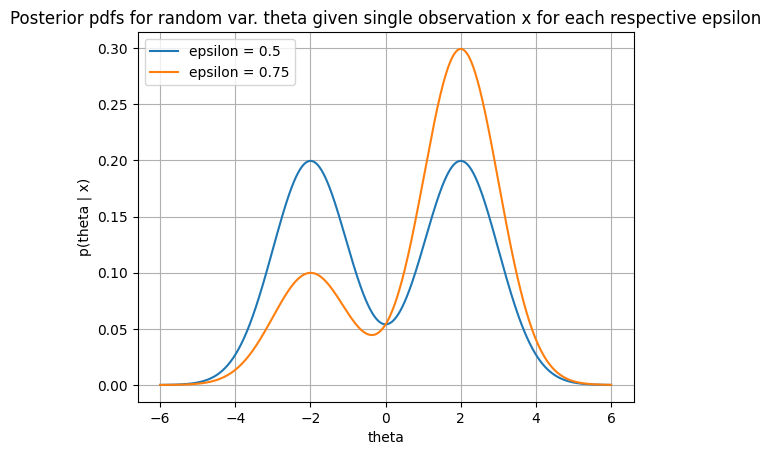

In [52]:
import numpy as np
import matplotlib.pyplot as plt

epsilons = [1/2, 3/4]
x_observed = 2
theta = np.linspace(-6, 6, 1000)

for epsilon in epsilons:
    p = ((epsilon / np.sqrt(2*np.pi)) * np.exp(-0.5 * (theta-x_observed)**2)) + (((1 - epsilon) / np.sqrt(2*np.pi)) * np.exp(-0.5 * (theta+x_observed)**2))

    plt.plot(theta, p, label=f"epsilon = {epsilon}")

plt.title("Posterior pdfs for random var. theta given single observation x for each respective epsilon")
plt.xlabel("theta")
plt.ylabel("p(theta | x)")
plt.legend()
plt.grid()

plt.show()

We see each gaussian is centered at x=2 and x=-2.

When epsilon = 1/2, both peaks have equal weights.

When epsilon = 3/4, the peak near +x is higher, because that Gaussian gets more weight.

When epsilon = 1/4, the peak near -x is higher, because that Gaussian gets more weight.